In [4]:
from astropy.io import fits
from astropy.wcs import WCS

In [5]:
import numpy as np

In [6]:
file = fits.open("../images/hlsp_ceers_jwst_nircam_nircam7_f444w_dr0.6_i2d.fits") # Header Data Unit

In [7]:
file.info()

Filename: ../images/hlsp_ceers_jwst_nircam_nircam7_f444w_dr0.6_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     375   ()      
  1  SCI_BKSUB     1 ImageHDU        75   (11500, 6500)   float64   
  2  SCI           1 ImageHDU        75   (11500, 6500)   float32   
  3  ERR           1 ImageHDU        10   (11500, 6500)   float32   
  4  CON           1 ImageHDU        10   (11500, 6500, 1)   int32   
  5  WHT           1 ImageHDU         9   (11500, 6500)   float32   
  6  VAR_POISSON    1 ImageHDU         9   (11500, 6500)   float32   
  7  VAR_RNOISE    1 ImageHDU         9   (11500, 6500)   float32   
  8  VAR_FLAT      1 ImageHDU         9   (11500, 6500)   float32   
  9  BKGD          1 ImageHDU        39   (11500, 6500)   float64   
 10  BKGMASK       1 ImageHDU        41   (11500, 6500)   uint8 (rescales to int8)   
 11  HDRTAB        1 BinTableHDU    820   6R x 405C   [23A, 5A, 3A, 51A, 7A, 13A, 3A, 5A, 7A, 10A, 4A, L, 

In [8]:
type(file)

astropy.io.fits.hdu.hdulist.HDUList

In [9]:
# SCI_BKSUB (1) — the background-subtracted science image. This is a CEERS-specific addition (standard JWST i2d files don't have it), and it's the extension you want to feed to photutils detection, since the background is already removed. 11500 × 6500 pixels, float64.

In [10]:
# SCI (2) — the science mosaic without background subtraction, in MJy/sr. Its header contains the WCS keywords you'll need to convert pixel coordinates to RA/Dec.

In [11]:
# ERR (3) — total 1σ uncertainty per pixel. This is what statmorph wants as its weightmap argument, and what you can pass to detect_sources logic for S/N thresholding.

In [12]:
sci = file[1].data 
err = file["ERR"].data
wcs = WCS(file["SCI"].header)
wht = file["WHT"].data

Set DATE-AVG to '2022-12-21T16:57:29.866' from MJD-AVG.
Set DATE-END to '2022-12-21T17:24:29.357' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.016438 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677602012.512 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [13]:
print(sci)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [14]:
print(err)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [15]:
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 214.825 52.825
CRPIX : 30718.5 8419.5
PC1_1 PC1_2  : -0.6467897795104595 -0.7626683296956883
PC2_1 PC2_2  : -0.7626683296956883 0.6467897795104595
CDELT : 8.33333333333333e-06 8.33333333333333e-06
NAXIS : 11500  6500


In [16]:
good = wht > 0

In [17]:

print(f"Total pixels: {sci.size}")
print(f"Pixels with coverage: {good.sum()} ({100*good.sum()/sci.size:.1f}%)")
print(f"SCI stats in covered region: min={sci[good].min():.4f}, "
      f"max={sci[good].max():.4f}, mean={sci[good].mean():.4f}")
print(f"NaNs in ERR within covered region: {np.isnan(err[good]).sum()}")

Total pixels: 74750000
Pixels with coverage: 37285769 (49.9%)
SCI stats in covered region: min=-0.3119, max=75.6904, mean=0.0052
NaNs in ERR within covered region: 0


In [18]:
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

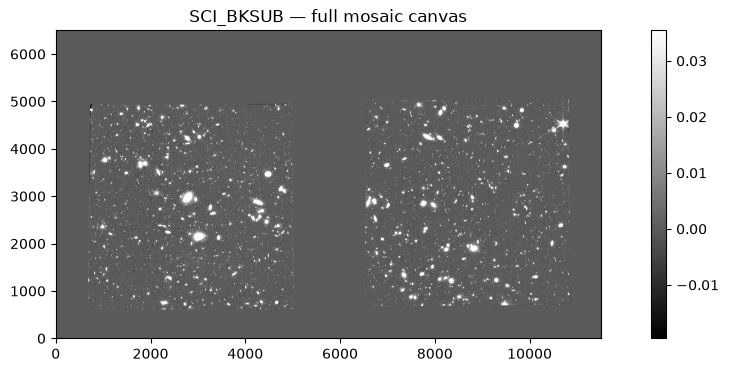

In [19]:
vmin, vmax = ZScaleInterval().get_limits(sci[good])
plt.figure(figsize=(13,4))
plt.imshow(sci, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.title("SCI_BKSUB — full mosaic canvas")
plt.colorbar()
plt.show()

In [33]:
type(sci)

numpy.ndarray

In [34]:
sci.shape

(6500, 11500)